**UNESCO dataset**

The UNESCO dataset includes World Heritage sites whose some are listed as “in danger.” It enables focusing on cultural sites and countries that are high-risk related.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_excel("../data/raw/whc-sites-2025.xlsx")
#df.columns
whc_sites = df[['states_name_en', 'danger']].copy()
for col in whc_sites.columns:
    whc_sites['states_name_en'] = whc_sites['states_name_en'].str.split(",").str[0].str.strip()
    #print(f"\n{col}")
    #print(whc_sites[col].dropna().unique())
whc_sites.head(2)

,states_name_en,danger
0,Afghanistan,1
1,Afghanistan,1


In [63]:
whc_sites_table = pd.pivot_table(whc_sites, values='states_name_en', index='states_name_en',
                       columns=['danger'], aggfunc="count", fill_value=0)

In [73]:
#whc_sites_table = whc_sites_table.reset_index()
#whc_sites_table  = whc_sites_table.rename(columns={0: "no_danger", 1: "yes_danger"})
#whc_sites_table.columns.name = None # remove danger column after pivot table
whc_sites_table['percent_danger'] = whc_sites_table['yes_danger'] / (whc_sites_table['no_danger']+ whc_sites_table['yes_danger'])
whc_sites_table.sort_values(by = "percent_danger", ascending=False).head(20)

,states_name_en,no_danger,yes_danger,percent_danger,rank
0,Afghanistan,0,2,1.000000,1
28,Central African Republic,0,1,1.000000,1
98,Micronesia (Federated States of),0,1,1.000000,1
147,Syrian Arab Republic,0,6,1.000000,1
138,Solomon Islands,0,1,1.000000,1
76,Jerusalem (Site proposed by Jordan),0,1,1.000000,1
41,Democratic Republic of the Congo,1,4,0.800000,2
164,Yemen,1,4,0.800000,2
86,Libya,1,4,0.800000,2
92,Mali,1,3,0.750000,3


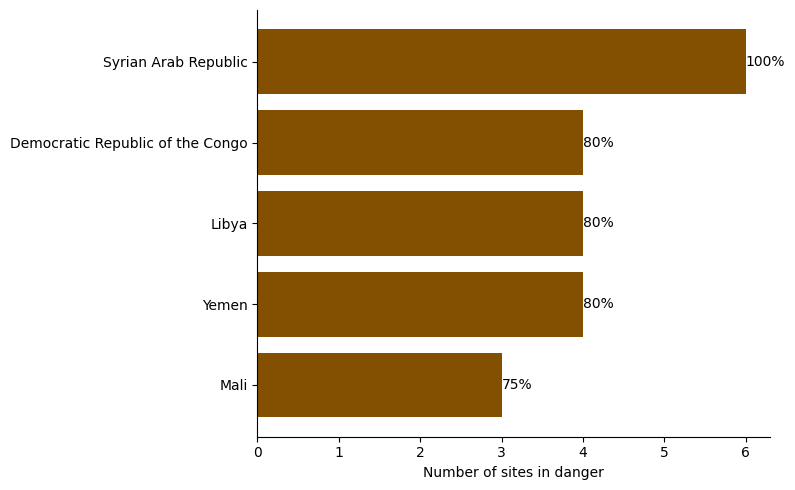

In [96]:
# top 5
top5 = whc_sites_table.sort_values(
    by=["yes_danger", "percent_danger", "states_name_en"],
    ascending=[False, False, True]
).head(5)

# colors to match with presentation graphic chart
accent = "#825000"       # brown
accent_light = "#D9A27E"
dark = "#333333"
mid = "#777777"

# plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    top5["states_name_en"],
    top5["yes_danger"],
    color=accent
)


ax.bar_label(
    ax.containers[0],
    labels=[f"{x*100:.0f}%" for x in top5["percent_danger"]]
)
    
# style
ax.invert_yaxis()
ax.set_xlabel("Number of sites in danger")

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


plt.tight_layout()
plt.savefig("../figures/top5_unesco_sites_danger.png", transparent=True)
plt.show()

In [97]:
whc_sites_table.to_csv("../data/raw/unesco_sites_in_danger.csv", index = False, sep = ";", encoding = "utf-8")